In [232]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
df = pd.read_csv("us_superstore_data.csv")
display(df)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [233]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [234]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [235]:
# Separando os dados para uma fazer a Análise
df_separated = df[["Row ID", "Order Date", "City", "State", "Category", "Sub-Category", "Sales", "Quantity", "Profit"]]
df_electronics = df_separated[df_separated["Category"] == "Technology"]
df_electronics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1847 entries, 7 to 9991
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        1847 non-null   int64  
 1   Order Date    1847 non-null   object 
 2   City          1847 non-null   object 
 3   State         1847 non-null   object 
 4   Category      1847 non-null   object 
 5   Sub-Category  1847 non-null   object 
 6   Sales         1847 non-null   float64
 7   Quantity      1847 non-null   int64  
 8   Profit        1847 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 144.3+ KB


In [236]:
# Verificando se tem valores nulos ou duplicados
print(f"Valores Duplicados:", df_electronics.duplicated().sum())
print(f"\nValores Nulos:", df_electronics.isnull().sum())

Valores Duplicados: 0

Valores Nulos: Row ID          0
Order Date      0
City            0
State           0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Profit          0
dtype: int64


In [237]:
# Verificando estatisticas basicas dos dados númericos
df_electronics.describe()

,Row ID,Sales,Quantity,Profit
count,1847.000000,1847.000000,1847.000000,1847.000000
mean,5003.331890,452.709276,3.756903,78.752002
std,2900.259785,1108.655848,2.216828,428.816633
min,8.000000,0.990000,1.000000,-6599.978000
25%,2513.000000,68.016000,2.000000,5.203650
50%,5054.000000,166.160000,3.000000,25.018200
75%,7546.500000,448.534000,5.000000,74.894600
max,9992.000000,22638.480000,14.000000,8399.976000


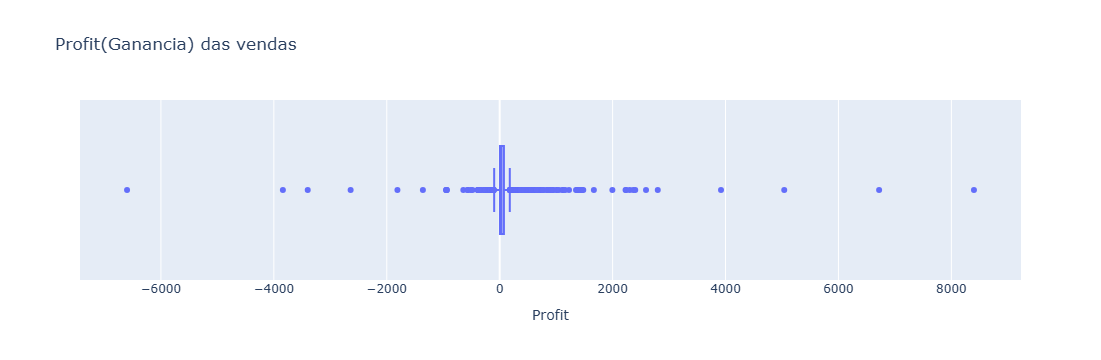

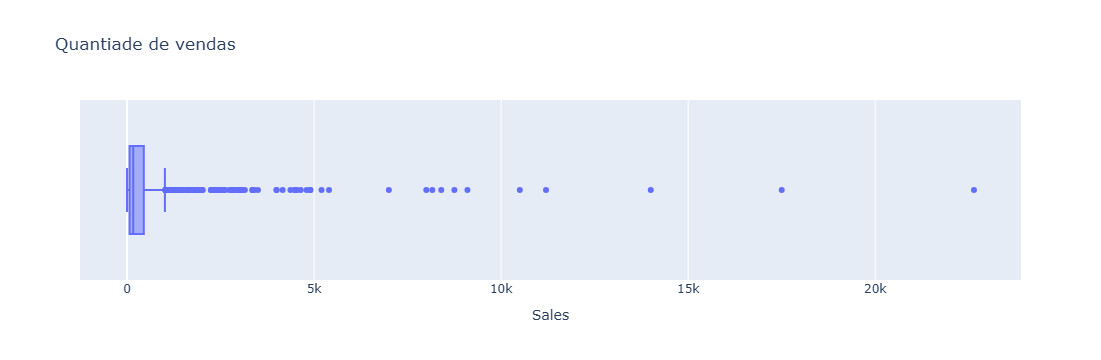

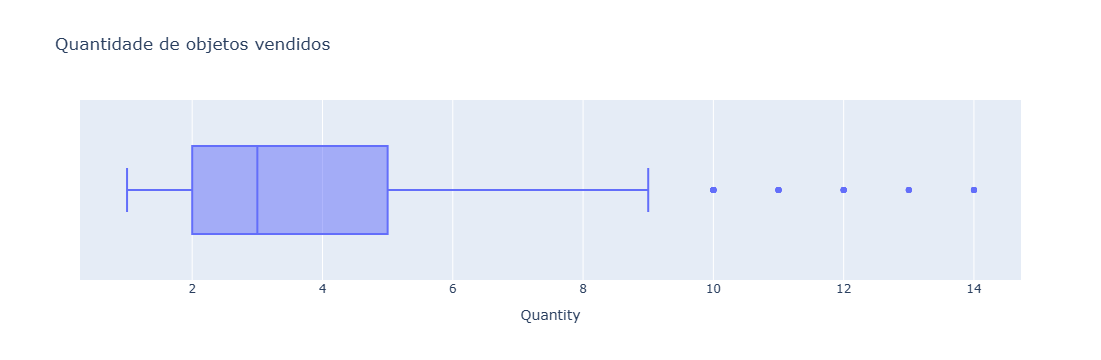

In [238]:
# Fazendo grafico de boxplot para identificar os outliers.
fig1 = px.box(df_electronics, x="Profit", title="Profit(Ganancia) das vendas")

fig2 = px.box(df_electronics, x="Sales", title="Quantiade de vendas")

fig3 = px.box(df_electronics, x="Quantity", title="Quantidade de objetos vendidos")

fig1.show()
fig2.show()
fig3.show()

In [239]:
# Tratando ouliers com os quartis
Q1 = df_electronics[["Sales", "Quantity", "Profit"]].quantile(0.25)
Q3 = df_electronics[["Sales", "Quantity", "Profit"]].quantile(0.75)
IQR = Q3 - Q1

# Definir limites para os outliers
outliers = (df_electronics[["Sales", "Quantity", "Profit"]] < (Q1 - 1.5 * IQR)) | (df_electronics[["Sales", "Quantity", "Profit"]] > (Q3 + 1.5 * IQR))

# Exibir as linhas com outliers
outliers_df = df_electronics[outliers.any(axis=1)]

# Filtrando dados para remoção de outliers
df_clean = df_electronics[~outliers.any(axis=1)]

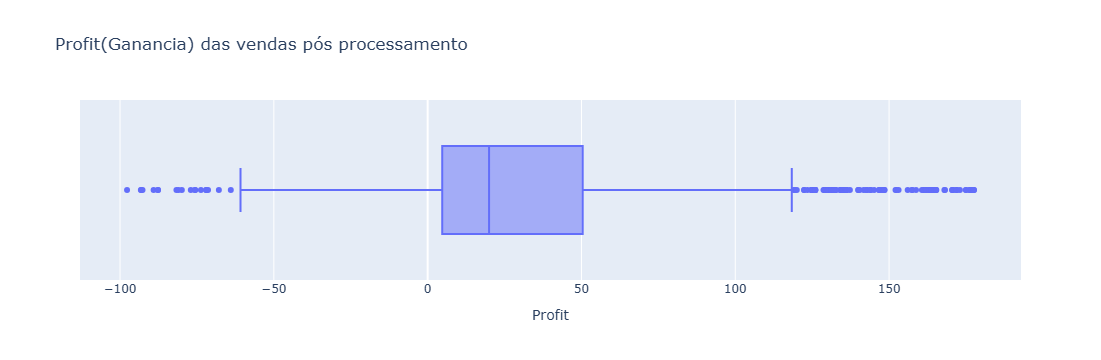

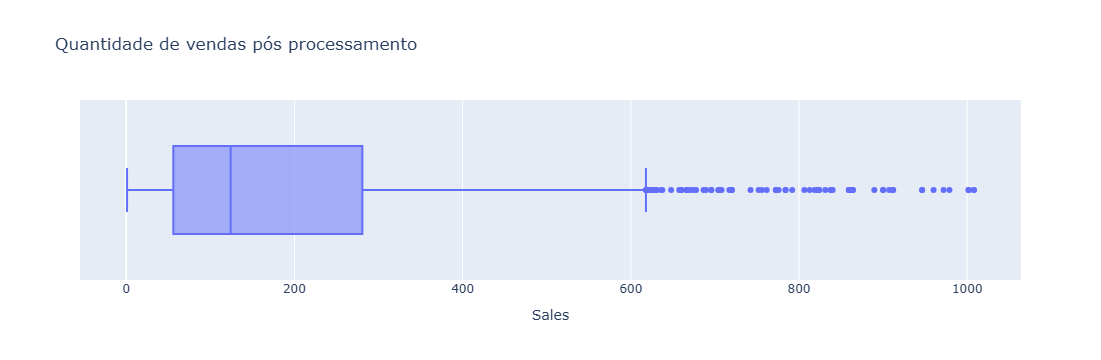

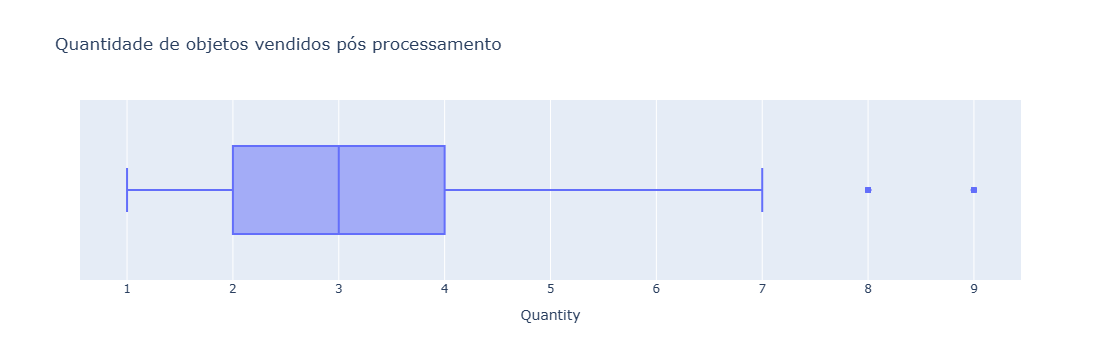

In [240]:
# Grafico bocplot depois de tratar os dados
fig1_clean = px.box(df_clean, x="Profit", title="Profit(Ganancia) das vendas pós processamento")

fig2_clean = px.box(df_clean, x="Sales", title="Quantidade de vendas pós processamento")

fig3_clean = px.box(df_clean, x="Quantity", title="Quantidade de objetos vendidos pós processamento")

fig1_clean.show()
fig2_clean.show()
fig3_clean.show()

In [241]:
# Garantir que 'df_clean' não seja uma cópia e sim uma instância independente
df_clean = df_clean.copy()

# Transformando a coluna "Order Date" a DateTime
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])

# Criando nova coluna com o nome Year_Month
df_clean["Year_Month"] = df_clean["Order Date"].dt.to_period("M")

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 7 to 9991
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        1545 non-null   int64         
 1   Order Date    1545 non-null   datetime64[ns]
 2   City          1545 non-null   object        
 3   State         1545 non-null   object        
 4   Category      1545 non-null   object        
 5   Sub-Category  1545 non-null   object        
 6   Sales         1545 non-null   float64       
 7   Quantity      1545 non-null   int64         
 8   Profit        1545 non-null   float64       
 9   Year_Month    1545 non-null   period[M]     
dtypes: datetime64[ns](1), float64(2), int64(2), object(4), period[M](1)
memory usage: 132.8+ KB


In [242]:
df_clean.describe()

,Row ID,Order Date,Sales,Quantity,Profit
count,1545.000000,1545,1545.000000,1545.000000,1545.000000
mean,5043.704207,2016-05-07 18:36:34.951456256,200.841707,3.400647,32.087697
min,8.000000,2014-01-06 00:00:00,0.990000,1.000000,-97.720000
25%,2556.000000,2015-05-30 00:00:00,55.992000,2.000000,4.779000
50%,5087.000000,2016-06-26 00:00:00,124.200000,3.000000,19.966500
75%,7621.000000,2017-05-25 00:00:00,280.782000,4.000000,50.396000
max,9992.000000,2017-12-30 00:00:00,1007.979000,9.000000,177.588900
std,2899.599390,NaN,197.950130,1.837117,44.501144


In [243]:
df_clean.isnull().sum()

Row ID          0
Order Date      0
City            0
State           0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Profit          0
Year_Month      0
dtype: int64

In [244]:
# Salvando Dataset limpo
df_clean.to_csv("../Pre-processamento/us-superstore_data_limpo.csv", index=False)
df_clean

,Row ID,Order Date,City,State,Category,Sub-Category,Sales,Quantity,Profit,Year_Month
7,8,2014-06-09,Los Angeles,California,Technology,Phones,907.152,6,90.7152,2014-06
11,12,2014-06-09,Los Angeles,California,Technology,Phones,911.424,4,68.3568,2014-06
19,20,2014-08-27,San Francisco,California,Technology,Phones,213.480,3,16.0110,2014-08
26,27,2016-01-16,Los Angeles,California,Technology,Accessories,90.570,3,11.7741,2016-01
40,41,2015-12-27,Houston,Texas,Technology,Phones,371.168,4,41.7564,2015-12
...,...,...,...,...,...,...,...,...,...,...
9983,9984,2016-09-22,Grand Rapids,Michigan,Technology,Phones,97.980,2,27.4344,2016-09
9986,9987,2016-09-29,Los Angeles,California,Technology,Accessories,36.240,1,15.2208,2016-09
9987,9988,2017-11-17,Athens,Georgia,Technology,Accessories,79.990,1,28.7964,2017-11
9988,9989,2017-11-17,Athens,Georgia,Technology,Phones,206.100,5,55.6470,2017-11


In [245]:
# Agrupando DataSet em State e Sub-Category e tirando o total de "Sales", "Quantity" e "Profit"
df_grouped1 = df_clean.groupby(["State", "Sub-Category"]).agg({"Sales":"sum", "Quantity":"sum", "Profit":"sum"}).reset_index()
df_organized1 = df_clean.groupby(["State", "Sub-Category"]).agg({"Sales":"sum", "Quantity":"sum", "Profit":"sum"}).reset_index().sort_values(by="Sales", ascending=False)

# Agrupando DataSet em State e Sub-Category e titando a media de "Sales", "Quantity" e "Profit"
df_grouped2 = df_clean.groupby(["State", "Sub-Category"]).agg(
    {"Sales":"mean", "Quantity":"mean", "Profit":"mean"}).reset_index()

# Agrupando DataSet em City e Sub-Caregory e tirando o total de "Sales", "Quantity" e "Profit"
df_grouped3 = df_clean.groupby(["City", "Sub-Category"]).agg({"Sales":"sum", "Quantity":"sum", "Profit":"sum"}).reset_index()
df_organized3 = df_clean.groupby(["City", "Sub-Category"]).agg(
    {"Sales":"mean", "Quantity":"mean", "Profit":"mean"}).reset_index().sort_values(by="Sales", ascending=False)

# Agrupando DataSet em State e Year e tirando a media de "Sales", "Quantity" e "Profit"
df_grouped4 = df_clean.groupby(["State", "Year_Month"]).agg({"Sales":"mean", "Quantity":"mean", "Profit":"mean"}).reset_index()

# Agrupar por estado e calcular a soma das vendas por mês
df_organized4 = df_clean.groupby(['State', 'Year_Month'])['Sales'].sum().reset_index()


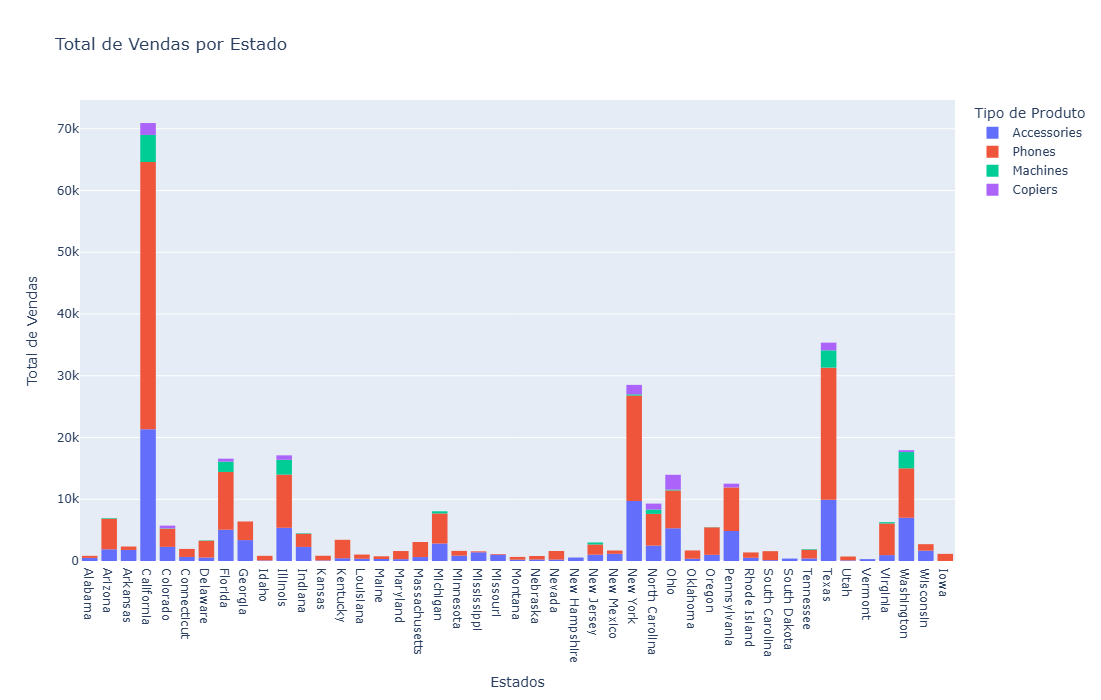

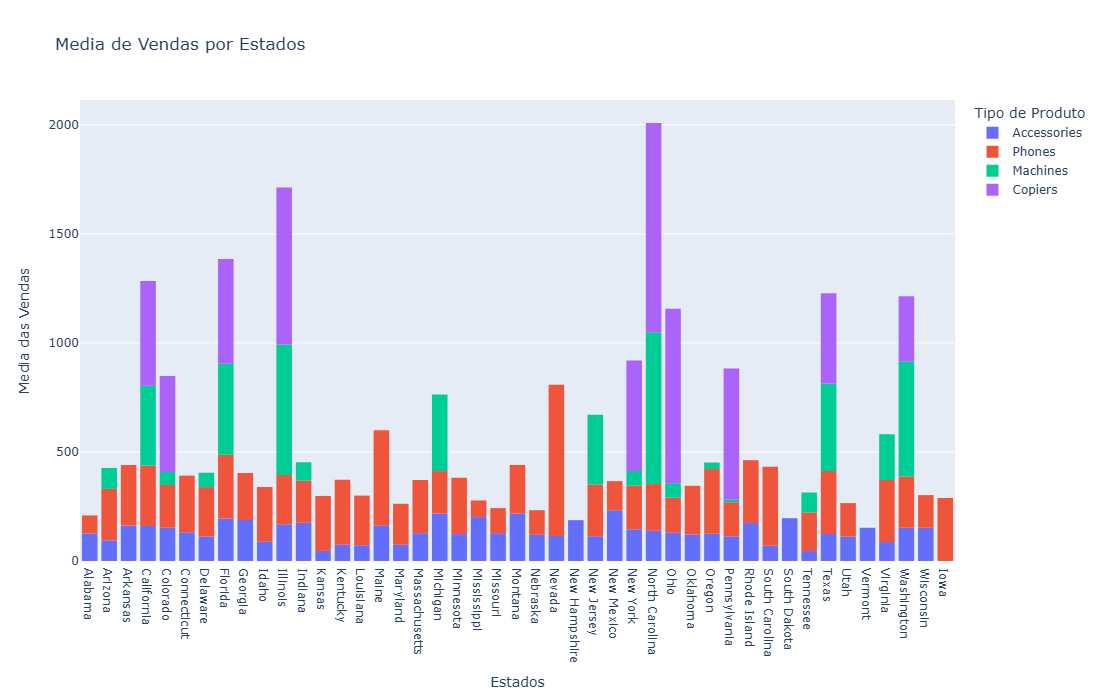

In [246]:
fig1 = px.histogram(df_grouped1, x="State", y="Sales", color="Sub-Category", title="Total de Vendas por Estado",labels={
    "State":"Estados",
    "Sales":"Total de Vendas",
    "Sub-Category":"Tipo de Produto"
    
}, height=700)

fig1.update_yaxes(title_text="Total de Vendas")

fig1.show()

fig2 = px.histogram(df_grouped2, x="State", y="Sales", color="Sub-Category", title="Media de Vendas por Estados", labels={
    "State":"Estados",
    "Sales":"Media de Vendas",
    "Sub-Category":"Tipo de Produto"
}, height=700)

fig2.update_yaxes(title_text="Media das Vendas")

fig2.show()

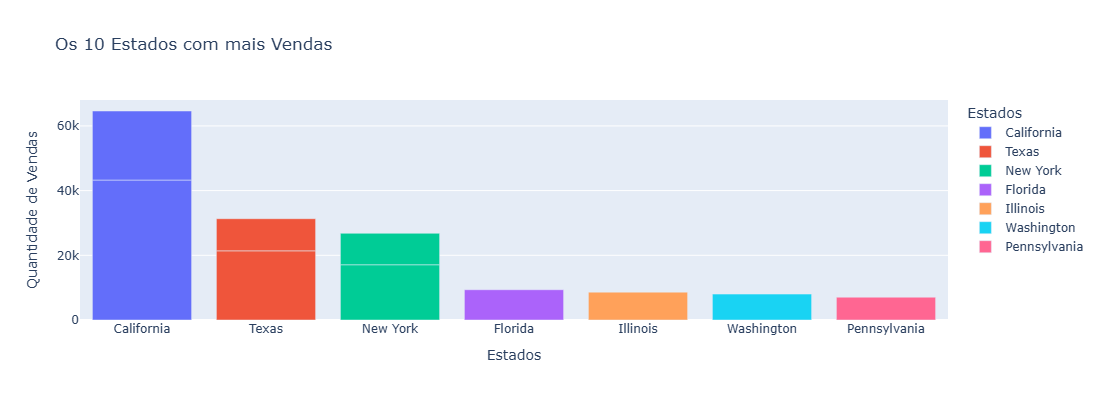

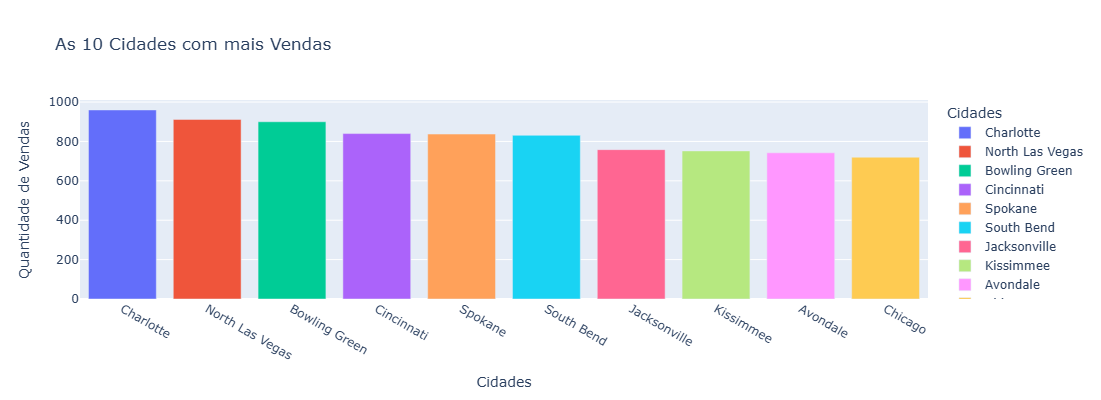

In [247]:
# Os Estados com mais Vendas
state_more_sales = df_organized1.head(10)
fig3 = px.bar(state_more_sales, x="State", y="Sales", color="State", title="Os 10 Estados com mais Vendas", labels={
    "State":"Estados",
    "Sales":"Quantidade de Vendas"
}, height=400)

# As Cidades com mais Vendas
city_more_sales = df_organized3.head(10)
fig4 = px.bar(city_more_sales, x="City", y="Sales", color="City", title="As 10 Cidades com mais Vendas", labels={
    "City":"Cidades",
    "Sales":"Quantidade de Vendas"
}, height=400)

fig3.show()
fig4.show()

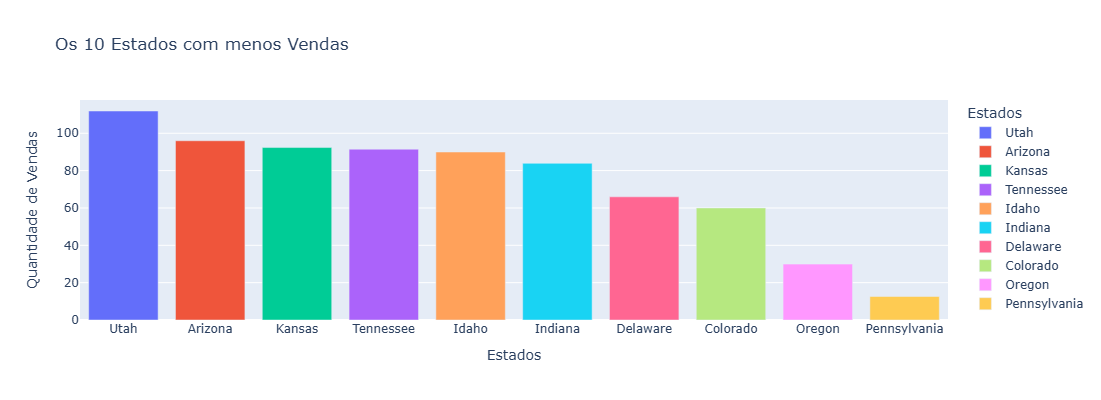

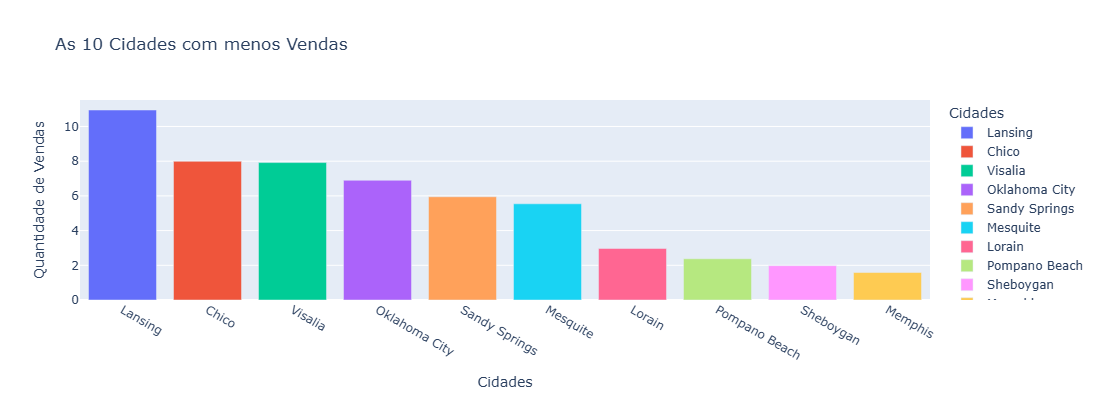

In [248]:
# Os Estados com menos Vendas
state_less_sales = df_organized1.tail(10)
fig5 = px.bar(state_less_sales, x="State", y="Sales", color="State", title="Os 10 Estados com menos Vendas", labels={
    "State":"Estados",
    "Sales":"Quantidade de Vendas"
}, height=400)

# As Cidades com menos Vendas
city_less_sales = df_organized3.tail(10)
fig6 = px.bar(city_less_sales, x="City", y="Sales", color="City", title="As 10 Cidades com menos Vendas", labels={
    "City":"Cidades", 
    "Sales":"Quantidade de Vendas"
}, height=400)

fig5.show()
fig6.show()

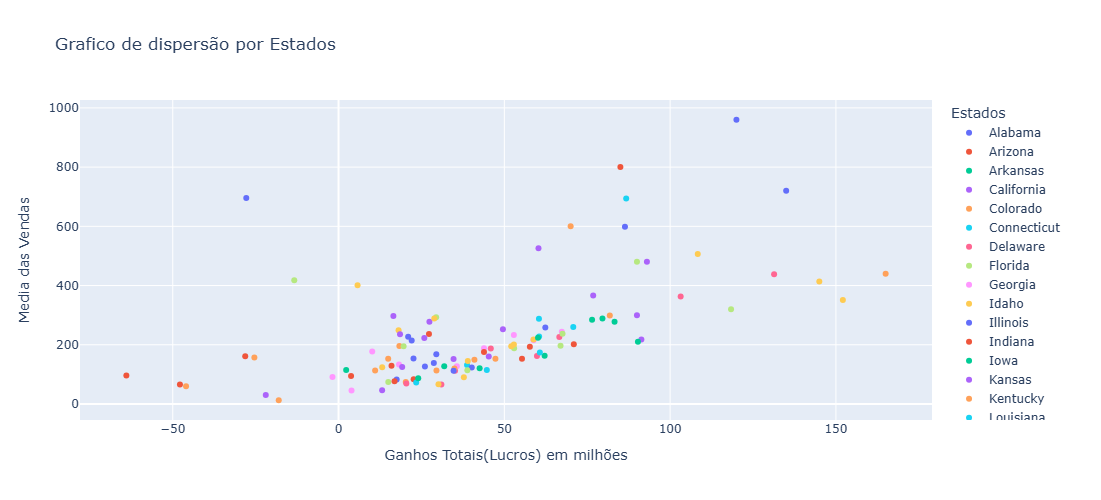

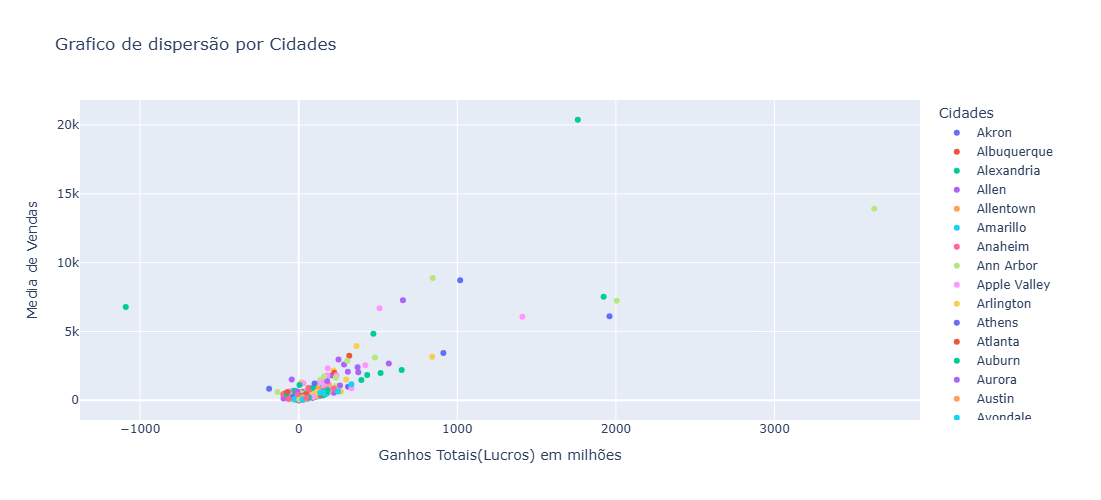

In [249]:
fig7 = px.scatter(df_grouped2, x="Profit", y="Sales", color="State", height=500, title="Grafico de dispersão por Estados",labels={
    "Profit":"Ganhos Totais(Lucros) em milhões",
    "Sales":"Media das Vendas",
    "State":"Estados"
})

fig8 = px.scatter(df_grouped3, x="Profit", y="Sales", color="City", height=500, title="Grafico de dispersão por Cidades", labels={
    "Profit":"Ganhos Totais(Lucros) em milhões",
    "Sales":"Media de Vendas",
    "City":"Cidades"
})

fig7.show()
fig8.show()

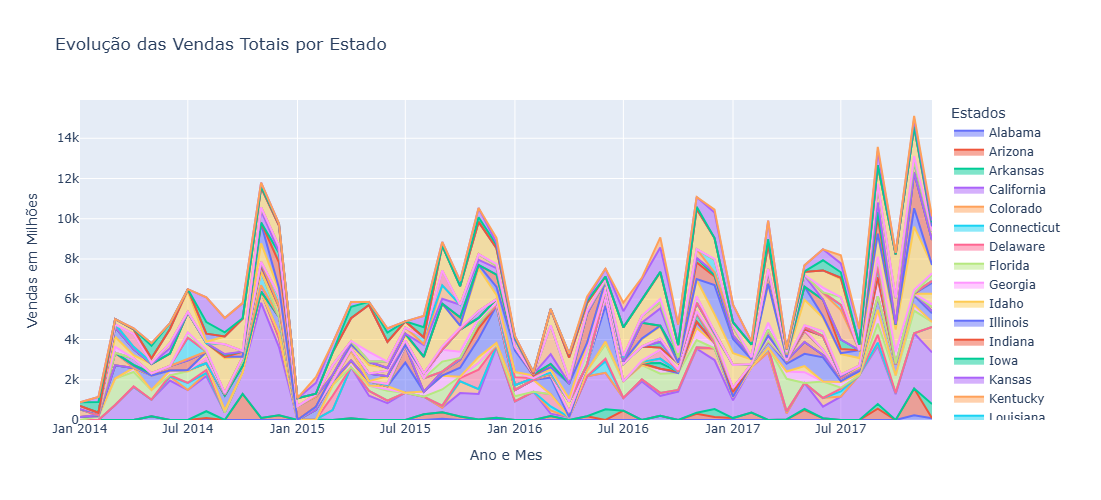

In [250]:
# Convertindo coluna "Year_Month" para Sting para que possa ser plotado no grafico
df_organized4["Year_Month"] = df_organized4["Year_Month"].astype(str)

fig10 = px.area(df_organized4, x="Year_Month", y="Sales", color="State",
             title="Evolução das Vendas Totais por Estado", labels={
                 "Year_Month":"Ano e Mes",
                 "Sales":"Vendas em Milhões",
                 "State":"Estados"
             }, height=500)

fig10.show()